In [2]:
# python libs
import glob
import os

# data libs
import pandas as pd
import torch

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

from IPython.display import display, clear_output

from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler

In [4]:
from sklearn.manifold import TSNE
import matplotlib as mpl

In [5]:
from Bio.Seq import Seq
from Bio import SeqIO

In [6]:
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Outline

Applying the ESM2-based model to Nick and Matt's isolated bacteria + Topt data for external validation of the methods

In [6]:
a, b = -20, 120

def forward_transform(y):
    eps = 1e-6  # to avoid division by zero
    y = np.clip(y, a + eps, b - eps)
    return np.log((y - a) / (b - y))

def inverse_transform(y_prime):
    return a + (b - a) / (1 + np.exp(-y_prime))

# Arthobacter

## Step 1. annotate genomes
From `/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Arthrobacter/genomes`  
`ls *.fasta > genome_list.txt`  
`~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm`  
`python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./`  
`cat ./genomes/*_adk.faa > adks.faa`  
` mafft --keeplength --add adks.faa ./../../20240122_all_adks_filtered.afa > keeplength_adk.afa`  
`clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa`  

In [116]:
arth_md = pd.read_csv('./../data/validation_datasets/Arthrobacter/md/2025_07_15-TOPT_Genomes.csv')


arth_genome2temp = arth_md.assign(id=arth_md['Genome_ID'].apply(lambda x: x.split('.fasta')[0])).set_index('id')['Topt']

arth_md.head()

,Group,Group2,Subproject,sample,EXP,Topt,Genome_ID
0,Antarctica,Antarctic Isolate,Antarctica,70B,EXP10B,16,barcode29_consensus.fasta
1,Antarctica,Antarctic Isolate,Antarctica,ASP_172-3(173-2),EXP10B,17,barcode36_consensus.fasta
2,Antarctica,Antarctic Isolate,Antarctica,ASP_190-3,EXP13,18,barcode03_consensus.fasta
3,Antarctica,Antarctic Isolate,Antarctica,ASP_192-5,EXP6,16,barcode38_consensus.fasta
4,Antarctica,Antarctic Isolate,Antarctica,ASP_29-2,EXP13,17,barcode48_consensus.fasta


In [117]:
arth_md

,Group,Group2,Subproject,sample,EXP,Topt,Genome_ID
0,Antarctica,Antarctic Isolate,Antarctica,70B,EXP10B,16,barcode29_consensus.fasta
1,Antarctica,Antarctic Isolate,Antarctica,ASP_172-3(173-2),EXP10B,17,barcode36_consensus.fasta
2,Antarctica,Antarctic Isolate,Antarctica,ASP_190-3,EXP13,18,barcode03_consensus.fasta
3,Antarctica,Antarctic Isolate,Antarctica,ASP_192-5,EXP6,16,barcode38_consensus.fasta
4,Antarctica,Antarctic Isolate,Antarctica,ASP_29-2,EXP13,17,barcode48_consensus.fasta
5,Antarctica,Antarctic Isolate,Antarctica,ASP_29-3,EXP13,17,barcode09_consensus.fasta
6,Antarctica,Antarctic Isolate,Antarctica,ASP_290-4,EXP13,16,barcode39_consensus.fasta
7,Antarctica,Antarctic Isolate,Antarctica,ASP_293-1,EXP12,17,barcode43_consensus.fasta
8,Antarctica,Antarctic Isolate,Antarctica,ASP_293-2,EXP9,14,barcode33_consensus.fasta
9,Antarctica,Antarctic Isolate,Antarctica,ASP_293-6,EXP10B,14,barcode24_consensus.fasta


In [105]:
# make mapping of sequence ID to sample ID
custom_mapping = {'barcode11_maxbin2.002':'barcode11',
                 'D14008_GCA_039539965.1_ASM3953996v1_genomic':'barcode14',
                 'D25586_GCA_003634095.1_ASM363409v1_genomic':'barcode50',
                 'DS72QC_1_ASP_418-1':'barcode19',
                  'DS72QC_2_ASP_410-4':'barcode13'
                 }

arth_record2sample = {}
tbls = glob.glob('./../data/validation_datasets/Arthrobacter/genomes/*_adk.faa')
for t in tbls:
    with open(t, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta')]
        for r in records:
            sample = t.split("/")[-1].replace('_adk.faa', '').replace('_consensus', '')
            if not sample in custom_mapping.keys():
                arth_record2sample[r.id] = sample
            else:
                arth_record2sample[r.id] = custom_mapping[sample]
print(len(arth_record2sample.keys()))

53


In [24]:

# curr_file = './../data/validation_datasets/Arthrobacter/adks.faa'

# with open(curr_file, 'r') as in_handle:
#     in_records = [r for r in SeqIO.parse(curr_file, format='fasta')]

# # go through records and add temperature
# out_records = []
# not_found = 0
# for r in in_records:
#     try:
#         new_temp = arth_genome2temp.loc[r.id.split("|")[1].replace("_hmmsearch.tbl", '')]
#         r.id = r.id.replace('XXXtemp=XXX', f'env_temp={new_temp}')
#         r.description = ''
#         out_records.append(r)
#     except KeyError:
#         not_found += 1
    
# with open(curr_file.replace('adk', 'adk_temp'), 'w') as out_handle:
#     SeqIO.write(out_records, out_handle, format='fasta')

In [107]:
arth_genome2temp = arth_md.assign(id=arth_md['Genome_ID'].apply(lambda x: x.split('.fasta')[0].replace('_consensus', ''))).set_index('id')['Topt']
arth_genome2temp.shape

(53,)

In [108]:
print(arth_genome2temp.reset_index().shape)
arth_genome2temp.reset_index().head()

(53, 2)


,id,Topt
0,barcode29,16
1,barcode36,17
2,barcode03,18
3,barcode38,16
4,barcode48,17


In [109]:
pd.Series(arth_record2sample).reset_index().head()

,index,0
0,contig_4_579|8HZ65L_1_ASP410-2_hmmsearch.tbl|X...,8HZ65L_1_ASP410-2
1,contig_1_2021|barcode02_consensus_hmmsearch.tb...,barcode02
2,contig_2_682|8HZ65L_3_24664_hmmsearch.tbl|XXXt...,8HZ65L_3_24664
3,contig_1_351|barcode01_consensus_hmmsearch.tbl...,barcode01
4,contig_1_919|barcode03_consensus_hmmsearch.tbl...,barcode03


In [110]:
merged = pd.merge(arth_genome2temp.reset_index(),
        pd.Series(arth_record2sample).reset_index(),
        left_on='id', right_on=0) 
print(merged.shape)
merged.head()

(53, 4)


,id,Topt,index,0
0,barcode29,16,contig_1_3549|barcode29_consensus_hmmsearch.tb...,barcode29
1,barcode36,17,contig_1_813|barcode36_consensus_hmmsearch.tbl...,barcode36
2,barcode03,18,contig_1_919|barcode03_consensus_hmmsearch.tbl...,barcode03
3,barcode38,16,contig_1_678|barcode38_consensus_hmmsearch.tbl...,barcode38
4,barcode48,17,contig_1_3312|barcode48_consensus_hmmsearch.tb...,barcode48


In [111]:
y = merged[['id', 'Topt', 'index']].rename(columns={'id':'sample_or_genome', 
                                                    'Topt':'env temp',
                                                   'index':'protein'})
y.head()

,sample_or_genome,env temp,protein
0,barcode29,16,contig_1_3549|barcode29_consensus_hmmsearch.tb...
1,barcode36,17,contig_1_813|barcode36_consensus_hmmsearch.tbl...
2,barcode03,18,contig_1_919|barcode03_consensus_hmmsearch.tbl...
3,barcode38,16,contig_1_678|barcode38_consensus_hmmsearch.tbl...
4,barcode48,17,contig_1_3312|barcode48_consensus_hmmsearch.tb...


In [112]:
y.to_csv('./../data/validation_datasets/Arthrobacter/md/Arthrobacter_env_temps.tsv', sep='\t')

## ensemble predictions from main model for arthrobacter species

here we go!!!!

Text(0.5, 1.0, 'Arthrobacter')

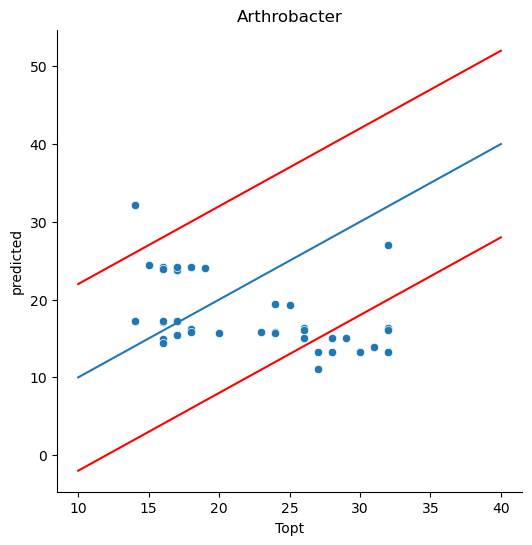

In [45]:
# ------------------------------------
# CAUTION: OLD CODE
# ------------------------------------
# WON'T RUN
# ------------------------------------
predictions = []
for col in list(col_datasets.keys()):
    # if col > 159 and col < 181: #in high_frac_sites[high_frac_sites < 0.5].index:
    predictions.append(pd.Series(index=col_datasets[col].T.index, data=inverse_transform(models[col].predict(col_datasets[col].T)), name=col))

y_pred = pd.concat(predictions, axis=1) 
y_pred.index = [s.split('|')[1].split('_hmm')[0] for s in y_pred.index]
y_mean = y_pred.mean(1).rename('predicted')
plotdf = pd.merge(y_mean, 
         y, 
         left_index=True, right_index=True)

fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=plotdf, y='predicted', x='Topt')

_x, _y = 10, 40
rmse = 12
plt.plot((_x, _y), (_x-rmse, _y-rmse), color='r')
plt.plot((_x, _y), (_x+rmse, _y+rmse), color='r')
plt.plot((_x, _y), (_x, _y))

sns.despine()

ax.set_title('Arthrobacter')

In [114]:
temp = pd.read_csv('./../data/validation_datasets/prediction_results/full_test_preds_isolates.tsv', sep='\t')

In [120]:
arth_md['genome'] = arth_md['Genome_ID'].apply(lambda x: x.replace('.fasta', '').replace('_consensus', ''))

In [123]:
temp[temp.dataset.eq('Arthrobacter')]

,Unnamed: 0,prediction,actual,protein,model_label,dataset,sample_or_genome,env temp
0,0,25.782515,16.0,contig_4_579|8HZ65L_1_ASP410-2_hmmsearch.tbl|X...,corkrey_lm_ind,Arthrobacter,8HZ65L_1_ASP410-2,16.0
1,1,19.282437,27.0,contig_2_682|8HZ65L_3_24664_hmmsearch.tbl|XXXt...,corkrey_lm_ind,Arthrobacter,8HZ65L_3_24664,27.0
2,2,30.133678,15.0,contig_1_351|barcode01_consensus_hmmsearch.tbl...,corkrey_lm_ind,Arthrobacter,barcode01,15.0
3,3,30.336291,17.0,contig_1_2021|barcode02_consensus_hmmsearch.tb...,corkrey_lm_ind,Arthrobacter,barcode02,17.0
4,4,17.191869,18.0,contig_1_919|barcode03_consensus_hmmsearch.tbl...,corkrey_lm_ind,Arthrobacter,barcode03,18.0
...,...,...,...,...,...,...,...,...
1214,48,32.535507,32.0,contig_1_3063|barcode53_consensus_hmmsearch.tb...,even_svr_means,Arthrobacter,barcode53,32.0
1215,49,25.362410,24.0,BAABED010000001.1_658|D14008_GCA_039539965.1_A...,even_svr_means,Arthrobacter,barcode14,24.0
1216,50,29.560352,25.0,RBIR01000002.1_325|D25586_GCA_003634095.1_ASM3...,even_svr_means,Arthrobacter,barcode50,25.0
1217,51,21.368881,12.0,contig_2_2269|DS72QC_1_ASP_418-1_hmmsearch.tbl...,even_svr_means,Arthrobacter,barcode19,12.0


In [127]:
plotdf = pd.merge(temp[temp.dataset.eq('Arthrobacter') & temp['model_label'].eq('corkrey_lm_ind_tuned_pca')],
         arth_md, left_on='sample_or_genome', right_on='genome', how='left')


<Axes: xlabel='actual', ylabel='prediction'>

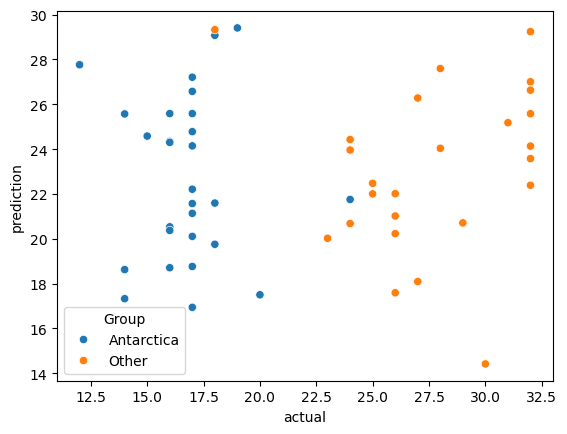

In [129]:
sns.scatterplot(data=plotdf, 
               x='actual', y='prediction', hue='Group')

# Mycobacteria

get accession list from `PRJNA1163726`
prefetch  
`~/tools/sratoolkit.2.11.3-centos_linux64/bin/prefetch --option-file ./../md/accessions.txt`  

Need to modify these scripts to specify an output directory
fasterq-dump  
`~/fiererlab/adenylate_kinase_ogt/scripts/fqd.sh`  
assemble (from `genomes`)  
`~/fiererlab/adenylate_kinase_ogt/scripts/spades.sh ./../md/accessions.txt`

In [383]:
import subprocess
from IPython.display import display, clear_output

In [388]:
# rename files
base = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Mycobacteria/genomes/'
scaffolds = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Mycobacteria/genomes/*_spades/scaffolds.fasta')
for i, sf in enumerate(scaffolds):

    display(i)
    clear_output(wait=True)
    
    genome = sf.split('/')[-2].split('_spades')[0]
    new_name = os.path.join(base, f'{genome}.fasta')
    subprocess.call(['cp', sf, new_name])

    # rename contigs
    with open(new_name, 'r') as handle:
        records  = [r for r in SeqIO.parse(handle, format='fasta')]

    for r in records:
        r.id = f'{r.id}|{genome}'
        r.description = ''

    with open(new_name, 'w') as handle:
        SeqIO.write(records, handle, format='fasta')

19

## Step 1. annotate genomes
From `/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/validation_datasets/Arthrobacter/genomes`  
```
ls *.fasta > genome_list.txt
~/fiererlab/adenylate_kinase_ogt/scripts/run_esm_pipeline.sh --genome-list genome_list.txt --hmm-model ~/fiererlab/adenylate_kinase_ogt/data/PF00406.hmm
python ~/fiererlab/adenylate_kinase_ogt/protein_utils/extract_adk.py -l ./
cat ./genomes/*_adk.faa > adks.faa
 mafft --keeplength --add adks.faa ./../../20240122_all_adks_filtered.afa > keeplength_adk.afa
clipkit keeplength_adk.afa -m gappy -o keeplength_adk_nogap.afa
```

In [52]:
myco_md = pd.read_excel('./../data/validation_datasets/Mycobacteria/md/MycoGrowthOptima_IsolateInformation-Detailed_Supplementary_Table1_vFinal_072025.xlsx')

In [53]:
sra_table = pd.read_csv('./../data/validation_datasets/Mycobacteria/md/myco_SraRunTable.csv')
myco_md_full = pd.merge(sra_table[['Sample Name', 'Run']].assign(sample=sra_table['Sample Name'].apply(lambda x: x.replace('NTM', 'NTM-'))),
         myco_md,
         left_on='sample',
         right_on='Isolate ID')
y = myco_md_full.set_index('Run')['Temperature Optimum (℃)']


In [54]:
# make mapping of sequence ID to sample ID
myco_record2sample = {}
tbls = glob.glob('./../data/validation_datasets/Mycobacteria/genomes/*_adk.faa')
for t in tbls:
    with open(t, 'r') as handle:
        records = [r for r in SeqIO.parse(handle, 'fasta')]
        for r in records:
            myco_record2sample[r.id] = t.split("/")[-1].replace('_adk.faa', '')

In [57]:
myco_genome2temp = myco_md_full.set_index('Run')['Temperature Optimum (℃)']

In [58]:
print(myco_genome2temp.reset_index().shape)
myco_genome2temp.reset_index().head()

(20, 2)


,Run,Temperature Optimum (℃)
0,SRR32180441,31.6
1,SRR32180442,38.2
2,SRR32180443,37.4
3,SRR32180444,32.8
4,SRR32180445,32.0


In [59]:
pd.Series(myco_record2sample).reset_index().head()

,index,0
0,NODE_8_length_214623_cov_14.510741|SRR32180443...,SRR32180443
1,NODE_9_length_205973_cov_23.464231|SRR32180444...,SRR32180444
2,NODE_5_length_244793_cov_26.942117|SRR32180441...,SRR32180441
3,NODE_64_length_33264_cov_17.408426|SRR32180442...,SRR32180442
4,NODE_1_length_1423141_cov_19.977692|SRR3218044...,SRR32180446


In [60]:
merged = pd.merge(myco_genome2temp.reset_index(),
        pd.Series(myco_record2sample).reset_index(),
        left_on='Run', right_on=0) 
print(merged.shape)
merged.head()

(20, 4)


,Run,Temperature Optimum (℃),index,0
0,SRR32180441,31.6,NODE_5_length_244793_cov_26.942117|SRR32180441...,SRR32180441
1,SRR32180442,38.2,NODE_64_length_33264_cov_17.408426|SRR32180442...,SRR32180442
2,SRR32180443,37.4,NODE_8_length_214623_cov_14.510741|SRR32180443...,SRR32180443
3,SRR32180444,32.8,NODE_9_length_205973_cov_23.464231|SRR32180444...,SRR32180444
4,SRR32180445,32.0,NODE_14_length_238297_cov_7.920280|SRR32180445...,SRR32180445


In [61]:
y = merged[['Run', 'Temperature Optimum (℃)', 'index']].rename(columns={'Run':'sample_or_genome', 
                                                    'Temperature Optimum (℃)':'env temp',
                                                   'index':'protein'})
y.head()

,sample_or_genome,env temp,protein
0,SRR32180441,31.6,NODE_5_length_244793_cov_26.942117|SRR32180441...
1,SRR32180442,38.2,NODE_64_length_33264_cov_17.408426|SRR32180442...
2,SRR32180443,37.4,NODE_8_length_214623_cov_14.510741|SRR32180443...
3,SRR32180444,32.8,NODE_9_length_205973_cov_23.464231|SRR32180444...
4,SRR32180445,32.0,NODE_14_length_238297_cov_7.920280|SRR32180445...


In [62]:
y.to_csv('./../data/validation_datasets/Mycobacteria/md/Mycobacteria_env_temps.tsv', sep='\t')

In [63]:
# curr_file = './../data/validation_datasets/Mycobacteria/adks.faa'

# with open(curr_file, 'r') as in_handle:
#     in_records = [r for r in SeqIO.parse(curr_file, format='fasta')]

# # go through records and add temperature
# out_records = []
# not_found = 0
# for r in in_records:
#     try:
#         new_temp = y.loc[r.id.split("|")[2].replace("_hmmsearch.tbl", '')]
#         r.id = r.id.replace('XXXtemp=XXX', f'env_temp={new_temp}')
#         r.description = ''
#         out_records.append(r)
#     except KeyError:
#         not_found += 1
    
# with open(curr_file.replace('adk', 'adk_temp'), 'w') as out_handle:
#     SeqIO.write(out_records, out_handle, format='fasta')

Text(0.5, 1.0, 'Mycobacteria')

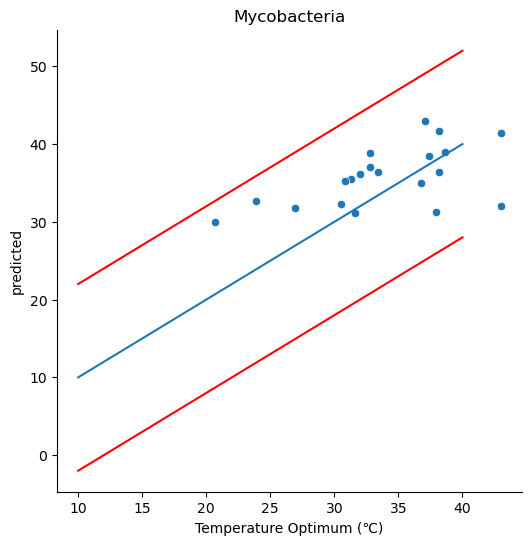

In [67]:
# ------------------------------------
# CAUTION: OLD CODE
# ------------------------------------
# WON'T RUN
# ------------------------------------
predictions = []
for col in list(col_datasets.keys()):
    if not col in [191, 192]:
        predictions.append(pd.Series(index=col_datasets[col].T.index, data=inverse_transform(models[col].predict(col_datasets[col].T)), name=col))

y_pred = pd.concat(predictions, axis=1) 
y_pred.index = [s.split('|')[2].split('_hmmsea')[0] for s in y_pred.index]
y_mean = y_pred.mean(1).rename('predicted')
plotdf = pd.merge(y_mean, 
         y, 
         left_index=True, right_index=True)

fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=plotdf, y='predicted', x='Temperature Optimum (℃)')

# for index, row in plotdf.iterrows():
#     if '032' in myco_md_full.set_index('Run')['sample'].loc[index]:
#         ax.annotate( myco_md_full.set_index('Run')['sample'].loc[index], (row['Temperature Optimum (℃)'], row['predicted']))
#         plt.scatter(y=row['predicted'], x=row['Temperature Optimum (℃)'], c='r')

_x, _y = 10, 40
rmse = 12
plt.plot((_x, _y), (_x-rmse, _y-rmse), color='r')
plt.plot((_x, _y), (_x+rmse, _y+rmse), color='r')
plt.plot((_x, _y), (_x, _y))

sns.despine()

ax.set_title('Mycobacteria')